# Notebook 2: Preprocessing, PCA, and K-Means Clustering

**Course:** Data Engineering - Unsupervised Learning Project  
**University:** Bar-Ilan University, Spring 2026  
**Dataset:** NYC PLUTO - 858,644 lots/buildings across New York City  

## Sections Covered

- **Section 1** - Data loading and feature role definitions  
- **Section 2** - Numeric conversion and coded-missing replacement  
- **Section 3** - Outlier capping (IQR winsorization)  
- **Section 4** - Feature engineering  
- **Section 5** - Missing-value removal and log transformation  
- **Section 6** - One-hot encoding and standardization  
- **Section 7** - PCA (approx. 90% variance)  
- **Section 8** - K-Means: elbow, silhouette, initialization sensitivity, full-space comparison  
- **Section 9** - Saving results and final summary  

## Research Question

How can we build, from the physical, functional, and geographical characteristics of the PLUTO dataset,
an unsupervised segmentation of NYC buildings to identify homogeneous urban profiles and analyze
their distribution across the five boroughs?

In [1]:
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42

---
## Section 1: Data Loading and Feature Role Definitions

In [2]:
# Locate the project root by walking up from the notebook's working directory.
# This makes the notebook runnable whether Jupyter is launched from the project
# root or from the notebook's own directory.
_search = Path.cwd()
for _ in range(5):
    if (_search / 'data' / 'raw').is_dir():
        PROJECT_ROOT = _search
        break
    _search = _search.parent
else:
    raise RuntimeError('Could not locate project root (expected a data/raw/ subdirectory).')

RAW_PATH       = PROJECT_ROOT / 'data' / 'raw' / 'pluto_working_copy.csv'
PROCESSED_DIR  = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR    = PROJECT_ROOT / 'reports' / 'figures'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df_raw = pd.read_csv(RAW_PATH, low_memory=False)
print(f'Dataset loaded: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns')
print(f'First 10 columns: {list(df_raw.columns[:10])}')

Dataset loaded: 858,644 rows, 101 columns
First 10 columns: ['borough', 'Tax block', 'Tax lot', 'community board', 'census tract 2010', 'cb2010', 'schooldist', 'council district', 'postcode', 'firecomp']


### Feature role definitions

Features are split into two non-overlapping roles before any transformation:

| Role | Features | Rationale |
|---|---|---|
| **Clustering input** | 13 source numerics + 3 engineered (16 total) | Measured physical and functional building characteristics |
| **Post-clustering only** | `borough`, `postcode`, `community board`, `latitude`, `longitude`, `assesstot`, `landuse` | Geographic, value, and categorical context reserved for blind validation after cluster assignment |

**Why exclude `borough` from clustering?**  
Borough is a coarse administrative label, not a building characteristic. Including it would bias K-Means toward geographic sub-regions rather than meaningful building typologies.

**Why exclude `landuse` from clustering?**  
`landuse` is a categorical label summarizing predominant use. Included as one-hot input, it dominates the distance calculation and K-Means simply recovers the input categories: cluster sizes mirror landuse-code frequencies rather than building morphology. `landuse` is instead used for blind validation - cross-tabulated against the discovered clusters in Section 9 to show what the morphology-based groups correspond to.

**Why exclude `assesstot` from clustering?**  
Total assessed value would reduce the segmentation to value-based groups, collapsing the problem into a form of regression. It is reserved for post-hoc cluster profiling.

In [3]:
# Source numeric columns needed before engineering
SOURCE_NUMERIC = [
    'lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth',
    'yearbuilt',
    'unitstotal', 'unitsres', 'resarea', 'comarea',
    'officearea', 'retailarea', 'garagearea', 'strgearea',
]

# Engineered clustering features (derived below)
ENGINEERED = ['building_age', 'building_density', 'residential_ratio']

# Clustering features: 16 numeric dimensions only.
# landuse is intentionally excluded; see Section 6 for the rationale.
CLUSTER_NUMERIC = [
    'lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth',
    'unitstotal', 'unitsres', 'resarea', 'comarea',
    'officearea', 'retailarea', 'garagearea', 'strgearea',
    'building_age', 'building_density', 'residential_ratio',
]

# Columns that receive log1p before scaling
LOG_COLS = [
    'lotarea', 'bldgarea', 'unitstotal', 'unitsres', 'resarea', 'comarea',
    'officearea', 'retailarea', 'garagearea', 'strgearea', 'building_density',
]

# Post-clustering interpretation columns (never fed to K-Means).
# landuse is here for blind post-hoc validation against discovered clusters.
POST_CLUSTER = [
    'borough', 'postcode', 'community board',
    'latitude', 'longitude', 'assesstot', 'landuse',
]

# Lot identifier
ID_COL = 'BBL'

# Columns to winsorize (IQR capping)
WINSORISE_COLS = ['lotarea', 'bldgarea', 'unitstotal', 'resarea', 'yearbuilt']

# Columns to load from the raw CSV
LOAD_COLS = [ID_COL] + SOURCE_NUMERIC + POST_CLUSTER

# Verify all requested columns exist
missing_cols = [c for c in LOAD_COLS if c not in df_raw.columns]
if missing_cols:
    raise ValueError(f'Columns not found in raw CSV: {missing_cols}')
print('All required columns present.')
print(f'Loading {len(LOAD_COLS)} columns from the raw dataset.')

df = df_raw[LOAD_COLS].copy()
print(f'Working frame shape: {df.shape}')

All required columns present.
Loading 22 columns from the raw dataset.
Working frame shape: (858644, 22)


---
## Section 2: Numeric Conversion and Coded-Missing Replacement

### 2.1 Numeric conversion

The raw CSV was exported with a Narrow No-Break Space (U+202F) as a thousands separator,
which is a French locale artifact. Values such as `"2 660"` must be stripped before conversion.
We use a regex that removes all whitespace variants (ASCII space, U+202F, U+00A0) and any
non-numeric character, then pass `errors='coerce'` so unparseable values become NaN.

In [4]:
# Strip thousands-separator whitespace and coerce to numeric
numeric_to_convert = SOURCE_NUMERIC + ['assesstot', 'latitude', 'longitude', 'postcode']

for col in numeric_to_convert:
    if col in df.columns:
        df[col] = (
            df[col].astype(str)
                   .str.replace(r'[\s\u202f\u00a0]', '', regex=True)
                   .str.replace(r'[^\d.\-]', '', regex=True)
                   .replace('', np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('Numeric conversion complete.')
print('dtypes sample:')
print(df[SOURCE_NUMERIC[:6]].dtypes)

Numeric conversion complete.
dtypes sample:
lotarea      float64
bldgarea     float64
numfloors    float64
lotfront     float64
lotdepth     float64
yearbuilt    float64
dtype: object


### 2.2 Replace coded-missing zeros with NaN

The PLUTO data dictionary documents `yearbuilt = 0` as "year unknown" and `bldgarea = 0` as
an unpopulated field. Both encode absence of information, not a real measurement of zero.
Treating them as zero would pull centroids toward nonsensical values (an age of 2026 years,
a building with no floor area). Replacing them with NaN lets the missing-value drop in
Section 5 handle them correctly.

In [5]:
n_yearbuilt_zero = (df['yearbuilt'] == 0).sum()
n_bldgarea_zero  = (df['bldgarea']  == 0).sum()

df.loc[df['yearbuilt'] == 0, 'yearbuilt'] = np.nan
df.loc[df['bldgarea']  == 0, 'bldgarea']  = np.nan

print(f'yearbuilt == 0 replaced with NaN: {n_yearbuilt_zero:,} rows ({n_yearbuilt_zero/len(df)*100:.2f}%)')
print(f'bldgarea  == 0 replaced with NaN: {n_bldgarea_zero:,}  rows ({n_bldgarea_zero/len(df)*100:.2f}%)')

yearbuilt == 0 replaced with NaN: 40,115 rows (4.67%)
bldgarea  == 0 replaced with NaN: 41,109  rows (4.79%)


---
## Section 3: Outlier Capping (IQR Winsorization)

### Why cap rather than delete?

EDA Notebook 2 detected extreme right-skew and IQR outliers on several area and count features.
Deleting outlier rows would discard up to 17% of the dataset for a single feature; the intersection
across features would remove far more. Winsorization (capping at Q1 - 1.5*IQR and Q3 + 1.5*IQR)
retains every row and limits the influence of extreme values without discarding information.

The five features flagged in Notebook 2 are: `lotarea`, `bldgarea`, `unitstotal`, `resarea`,
`yearbuilt`. `numfloors` is handled separately with a hard cap of 104 (One World Trade Center),
because values above 104 are parsing artifacts identified in Notebook 1, not genuine outliers.

In [6]:
# Hard cap: numfloors > 104 are data-entry artifacts, not real buildings
n_floors_capped = (df['numfloors'] > 104).sum()
df.loc[df['numfloors'] > 104, 'numfloors'] = np.nan
print(f'numfloors > 104 set to NaN: {n_floors_capped:,} rows')

# IQR winsorization for the five flagged features
cap_stats = []
for col in WINSORISE_COLS:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lo  = q1 - 1.5 * iqr
    hi  = q3 + 1.5 * iqr
    n_lo = (df[col] < lo).sum()
    n_hi = (df[col] > hi).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    cap_stats.append({'feature': col, 'lower_cap': round(lo, 2), 'upper_cap': round(hi, 2),
                      'rows_capped_low': n_lo, 'rows_capped_high': n_hi})

print('\nIQR capping summary:')
print(pd.DataFrame(cap_stats).to_string(index=False))

numfloors > 104 set to NaN: 27,069 rows



IQR capping summary:
   feature  lower_cap  upper_cap  rows_capped_low  rows_capped_high
   lotarea    -1000.0     7000.0                0             74061
  bldgarea     -987.5     5592.5                0             90052
unitstotal       -0.5        3.5                0            110558
   resarea     -590.0     4354.0                0             74429
 yearbuilt     1860.0     2020.0             4037              5911


---
## Section 4: Feature Engineering

Three derived features are created from the winsorized source columns, before any log transform.
This order matters: log1p compresses values, which would change the denominators and numerators
used in the ratios and the age computation.

| Feature | Formula | Interpretation |
|---|---|---|
| `building_age` | `2026 - yearbuilt` | Years elapsed since construction; 2026 is the analysis reference year |
| `building_density` | `bldgarea / lotarea` | Floor-area ratio proxy; how intensively a lot is built upon |
| `residential_ratio` | `unitsres / unitstotal` | Share of residential units; 0 = unit-less building, 1 = purely residential |

**NaN vs zero semantics for `residential_ratio`:**
A building with `unitstotal == 0` (e.g. a parking lot, vacant land, utility infrastructure)
has no units at all, making it 0% residential. This is a real, informative value, not missing
data. Setting it to NaN would silently drop all commercial, industrial, and unit-less buildings
from the clustering - exactly the non-residential diversity we want to preserve. NaN is
reserved strictly for rows where `unitstotal` or `unitsres` is itself absent from the source.

Both ratio features use `np.where` with explicit NaN branches, and an extra `replace` call
removes any residual Inf values that could slip through winsorization near-zero edge cases
(`dropna` does not catch Inf).

In [7]:
# building_age: yearbuilt already NaN where year was unknown (0)
df['building_age'] = 2026 - df['yearbuilt']

# building_density: NaN when lot has no area (np.where avoids inf)
df['building_density'] = np.where(
    df['lotarea'].notna() & (df['lotarea'] > 0),
    df['bldgarea'] / df['lotarea'],
    np.nan
)

# residential_ratio: unitsres / unitstotal (NOT resarea / bldgarea)
#   - NaN  when either unitstotal or unitsres is genuinely missing
#   - 0.0  when unitstotal == 0: the building has no units (parking lot, vacant land,
#          utility site, etc.); it is 0% residential, not missing information.
#          Keeping this as 0 retains commercial/industrial/unit-less buildings in the
#          clustering instead of silently dropping them via dropna.
#   - ratio when unitstotal > 0
df['residential_ratio'] = np.where(
    df['unitstotal'].isna() | df['unitsres'].isna(),
    np.nan,
    np.where(
        df['unitstotal'] > 0,
        df['unitsres'] / df['unitstotal'],
        0.0
    )
)

# Safety: replace any Inf that could survive winsorization near-zero edges.
# dropna does not catch Inf, so this guard is necessary.
df[ENGINEERED] = df[ENGINEERED].replace([np.inf, -np.inf], np.nan)

print('Engineered feature statistics:')
df[ENGINEERED].describe().round(3)

Engineered feature statistics:


,building_age,building_density,residential_ratio
count,818203.000,816739.000,858199.000
mean,84.356,0.923,1.652
std,31.561,0.597,9.765
min,6.000,0.000,0.000
25%,66.000,0.525,1.000
50%,95.000,0.786,1.000
75%,106.000,1.142,1.000
max,166.000,90.202,3118.286


---
## Section 5: Drop Rows with Missing Clustering Values

After coded-zero replacement and feature engineering, some rows still have NaN in at least one
clustering feature. K-Means cannot operate on missing values, and the only lossless option
at this stage is row removal. Imputation with the median (a common shortcut) would distort
cluster geometry by pulling missing-value rows toward the center of the distribution,
making them artificially similar to one another rather than reflecting their true profile.

A safety guard stops the pipeline if more than 30% of rows would be dropped.

In [8]:
# Clustering features: 16 numeric dimensions, no categorical columns
ALL_CLUSTER_COLS = CLUSTER_NUMERIC

n_before = len(df)
df_clean = df.dropna(subset=ALL_CLUSTER_COLS).reset_index(drop=True)
n_after  = len(df_clean)
n_dropped  = n_before - n_after
pct_dropped = n_dropped / n_before * 100

print(f'Rows before drop: {n_before:,}')
print(f'Rows after drop:  {n_after:,}')
print(f'Rows dropped:     {n_dropped:,} ({pct_dropped:.2f}%)')

if pct_dropped > 30:
    raise RuntimeError(
        f'Data loss too high: {pct_dropped:.1f}% of rows dropped (threshold 30%). '
        'Review imputation or column selection before proceeding.'
    )

print('Data loss is within the 30% threshold. Proceeding.')

Rows before drop: 858,644
Rows after drop:  782,299
Rows dropped:     76,345 (8.89%)
Data loss is within the 30% threshold. Proceeding.


## Section 5b: Log1p Transformation on Skewed Features

K-Means uses Euclidean distance. A feature like `lotarea` that spans several orders of magnitude
(hundreds to millions of square feet) dominates every distance calculation, rendering all other
features irrelevant to cluster assignment. `log1p(x) = log(1 + x)` compresses the scale while
safely handling zeros (unlike `log(x)`, which is undefined at 0) and preserving rank order.

Features **not** log-transformed: `numfloors`, `lotfront`, `lotdepth`, `building_age`,
`residential_ratio`. These are already on compact, approximately linear scales.

In [9]:
# Compute skewness before transformation for documentation
skew_before = df_clean[LOG_COLS].skew().round(2)

df_log = df_clean.copy()
for col in LOG_COLS:
    df_log[col] = np.log1p(df_log[col])

skew_after = df_log[LOG_COLS].skew().round(2)

skew_comparison = pd.DataFrame({'skewness_raw': skew_before, 'skewness_log1p': skew_after})
print('Skewness before and after log1p:')
print(skew_comparison.to_string())

Skewness before and after log1p:
                  skewness_raw  skewness_log1p
lotarea                   1.18            0.26
bldgarea                  1.07            0.19
unitstotal                0.51            0.17
unitsres                125.51            2.65
resarea                   0.64           -3.29
comarea                 167.55            2.26
officearea               84.36            5.58
retailarea              151.09            3.16
garagearea              186.98            9.05
strgearea               215.72           10.84
building_density          2.41            0.79


---
## Section 6: Clustering Feature Matrix and Standardization

### Why landuse is excluded from the clustering features

`landuse` encodes the predominant use of a lot as a categorical code (1 = One/Two-Family,
5 = Commercial/Office, 6 = Industrial, etc.). Including it as a one-hot input causes two
compounding problems:

1. **Signal dominance.** Each binary column produced by one-hot encoding is exactly 0 or 1
   with no within-category variation. After StandardScaler the binary indicators carry
   disproportionate geometric weight relative to continuous physical features such as
   `bldgarea` or `numfloors`, which vary naturally within each land use type.

2. **Disguised re-labeling.** In practice, K-Means with one-hot landuse input recovers the
   input categories rather than discovering new structure. The cluster sizes mirror landuse-code
   frequencies, and the "segmentation" reports only what the original labels already encoded.

**Approach:** cluster on measured physical and functional building characteristics only (16
numeric features), then cross-tabulate the discovered clusters against `landuse` and `borough`
in Section 9 as a blind validation. If the discovered clusters correlate with land use, that
correlation is a finding - not an artifact of feeding the label in as input.

In [10]:
# Clustering matrix: 16 numeric features, no one-hot encoding.
# landuse is excluded to prevent recovering input labels as clusters.
df_encoded = df_log[CLUSTER_NUMERIC].copy()

print(f'Clustering matrix: {df_encoded.shape[0]:,} rows x {df_encoded.shape[1]} features')
print(list(df_encoded.columns))

Clustering matrix: 782,299 rows x 16 features
['lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth', 'unitstotal', 'unitsres', 'resarea', 'comarea', 'officearea', 'retailarea', 'garagearea', 'strgearea', 'building_age', 'building_density', 'residential_ratio']


### 6.2 StandardScaler

After log transformation the distributions are approximately normal, but features still have
different variances. `numfloors` ranges from 1 to 104; `building_age` ranges from 1 to ~175.
Without scaling, features with higher variance dominate Euclidean distance. StandardScaler
transforms every feature to mean = 0 and std = 1, so each contributes equally to distance
regardless of its original unit.

The scaler is fitted on the full cleaned dataset (no train/test split for unsupervised learning)
and saved to disk with `joblib` so cluster centroids can be inverse-transformed in later notebooks.

In [11]:
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(df_encoded)
X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=df_encoded.columns,
    index=df_clean.index
)

# Save the fitted scaler for centroid inverse-transformation in later notebooks
scaler_path = PROCESSED_DIR / 'scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f'Scaler saved to {scaler_path}')

print(f'Scaled matrix shape: {X_scaled.shape}')
print(f'Mean check (should be ~0): {X_scaled.mean().abs().max():.2e}')
print(f'Std check  (should be ~1): {X_scaled.std().mean():.4f}')

Scaler saved to /Users/ouriouahba/Desktop/NYC_PLUTO/data/processed/scaler.pkl
Scaled matrix shape: (782299, 16)
Mean check (should be ~0): 1.73e-15
Std check  (should be ~1): 1.0000


In [12]:
# Save the scaled clustering matrix
scaled_path = PROCESSED_DIR / 'pluto_scaled.csv'
X_scaled.to_csv(scaled_path, index=True)
print(f'Scaled matrix saved to {scaled_path}')

# Companion file: original (un-scaled) clustering values + all post-clustering columns + ID.
# POST_CLUSTER includes landuse for blind post-hoc cross-tabulation against clusters.
companion_cols = [ID_COL] + CLUSTER_NUMERIC + POST_CLUSTER
companion = df_clean[companion_cols].copy()
companion_path = PROCESSED_DIR / 'pluto_companion.csv'
companion.to_csv(companion_path, index=True)
print(f'Companion file saved to {companion_path}')
print(f'Companion shape: {companion.shape}')

Scaled matrix saved to /Users/ouriouahba/Desktop/NYC_PLUTO/data/processed/pluto_scaled.csv


Companion file saved to /Users/ouriouahba/Desktop/NYC_PLUTO/data/processed/pluto_companion.csv
Companion shape: (782299, 24)


---
## Section 7: PCA

### Why reduce dimensionality before K-Means?

The clustering matrix has 16 numeric dimensions. Several of these features are correlated:
`unitsres` and `resarea` share most of their variance (Pearson r ~ 0.90), and the commercial
area breakdowns (`comarea`, `officearea`, `retailarea`) move together. PCA projects the data
onto the directions of maximum variance, decorrelating features and compressing noise while
preserving the structure that drives cluster separation.

Even with 16 dimensions, the curse of dimensionality can degrade Euclidean distance quality:
as dimensions grow, pairwise distances become increasingly uniform, making centroid assignment
less discriminative. We retain enough components to explain approximately 90% of cumulative
variance as a principled balance between information retention and dimensionality reduction.
The full-space vs PCA-space silhouette comparison in Section 8c provides an empirical check.

Components needed to reach 90% cumulative variance: 11
Cumulative variance at 11 components: 93.20%


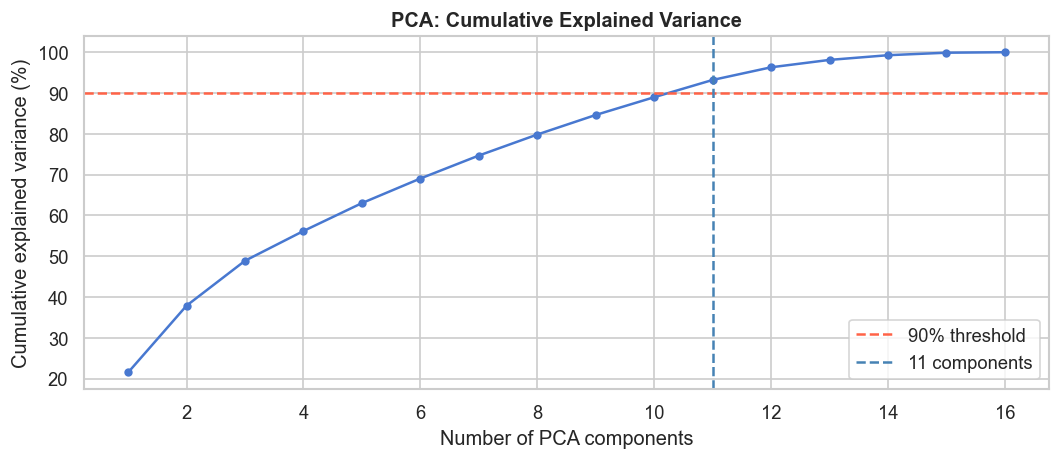

Figure saved.


In [13]:
# Full-rank PCA to determine how many components reach 90% cumulative variance
pca_search = PCA(random_state=RANDOM_STATE)
pca_search.fit(X_scaled)
cumvar = np.cumsum(pca_search.explained_variance_ratio_)

n_components = int(np.searchsorted(cumvar, 0.90)) + 1
print(f'Components needed to reach 90% cumulative variance: {n_components}')
print(f'Cumulative variance at {n_components} components: {cumvar[n_components-1]*100:.2f}%')

# Plot cumulative variance curve
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, marker='o', markersize=4)
ax.axhline(90, color='tomato', linestyle='--', label='90% threshold')
ax.axvline(n_components, color='steelblue', linestyle='--',
           label=f'{n_components} components')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('PCA: Cumulative Explained Variance', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_pca_cumulative_variance.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

In [14]:
# Fit the final PCA with the chosen number of components
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca_array = pca.fit_transform(X_scaled)
X_pca = pd.DataFrame(
    X_pca_array,
    index=X_scaled.index,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

# Save PCA object and transformed matrix
joblib.dump(pca, PROCESSED_DIR / 'pca.pkl')
X_pca.to_csv(PROCESSED_DIR / 'pluto_pca.csv', index=True)
print(f'PCA object saved.  PCA matrix shape: {X_pca.shape}')

PCA object saved.  PCA matrix shape: (782299, 11)


---
## Section 8: K-Means Clustering

### Sampling

K-Means on the full cleaned dataset (700k+ rows) would take many minutes per fit and many
iterations across k values and configurations. We draw a stratified-equivalent random sample
of 50,000 rows (sufficient to represent the full distribution of NYC building types) for all
clustering runs. `random_state = 42` is used for reproducibility.

**Silhouette protocol (used consistently in all experiments):**  
`silhouette_score(X, labels, sample_size=10000, random_state=42)`  
where `X` is the 50,000-row sample. The internal `sample_size=10000` is sklearn's own
sub-sampling to keep computation tractable. Using this protocol in every cell ensures that
silhouette values are comparable across experiments.

In [15]:
sample_idx = X_scaled.sample(n=50_000, random_state=RANDOM_STATE).index
X_scaled_sample = X_scaled.loc[sample_idx]
X_pca_sample    = X_pca.loc[sample_idx]

print(f'Sample drawn: {len(sample_idx):,} rows')
print(f'PCA sample shape:    {X_pca_sample.shape}')
print(f'Full-space sample shape: {X_scaled_sample.shape}')

Sample drawn: 50,000 rows
PCA sample shape:    (50000, 11)
Full-space sample shape: (50000, 16)


### 8a: Primary K-Means in PCA Space - Elbow and Silhouette

We evaluate k = 2 to 8. The chosen k is the one that maximises the silhouette score.
The elbow plot provides a secondary visual check; if no sharp bend is visible, we note
that explicitly and rely on the silhouette criterion.

In [16]:
k_range = range(2, 9)
inertias    = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_pca_sample, labels,
                           sample_size=10_000, random_state=RANDOM_STATE)
    silhouettes.append(sil)
    print(f'k={k}  inertia={km.inertia_:>12.1f}  silhouette={sil:.4f}')

best_k_idx    = int(np.argmax(silhouettes))
best_k        = list(k_range)[best_k_idx]
best_sil_pca  = silhouettes[best_k_idx]
print(f'\nChosen k = {best_k}  (silhouette = {best_sil_pca:.4f})')

k=2  inertia=    570137.7  silhouette=0.4908


k=3  inertia=    486181.3  silhouette=0.2856


k=4  inertia=    439817.9  silhouette=0.2572


k=5  inertia=    397466.0  silhouette=0.2659


k=6  inertia=    359141.0  silhouette=0.2651


k=7  inertia=    328123.8  silhouette=0.2715


k=8  inertia=    300408.4  silhouette=0.2852

Chosen k = 2  (silhouette = 0.4908)


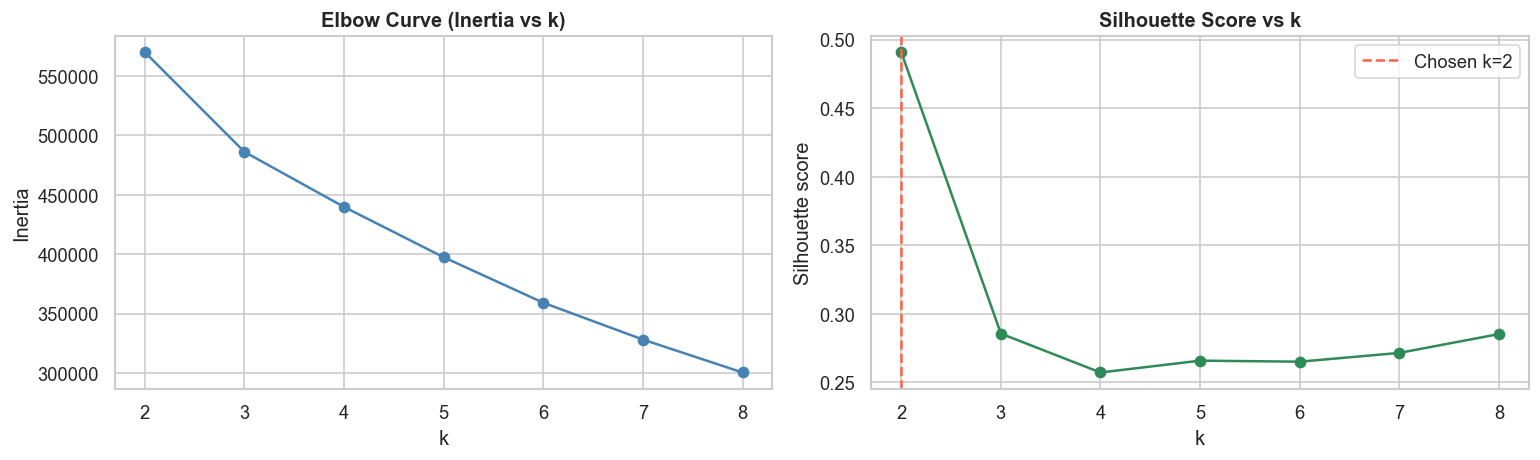

An inflection point is visible in the elbow curve; the silhouette criterion confirms the selection.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
k_list = list(k_range)

# Elbow plot
axes[0].plot(k_list, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Curve (Inertia vs k)', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(k_list)

# Silhouette plot
axes[1].plot(k_list, silhouettes, marker='o', color='seagreen')
axes[1].axvline(best_k, linestyle='--', color='tomato', label=f'Chosen k={best_k}')
axes[1].set_title('Silhouette Score vs k', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_xticks(k_list)
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_kmeans_elbow_silhouette.png', bbox_inches='tight')
plt.show()

# Elbow interpretation
diffs = np.diff(inertias)
if max(abs(diffs)) / inertias[0] < 0.05:
    print('Note: The elbow curve shows no sharp bend. '
          'The silhouette criterion is used as the primary selection rule.')
else:
    print('An inflection point is visible in the elbow curve; '
          'the silhouette criterion confirms the selection.')

### 8b: Initialization Sensitivity Demo

K-Means is sensitive to the random initial centroid placement. With `n_init=1`, a single
random initialization may converge to a poor local minimum. With `n_init=10`, the algorithm
runs 10 independent initializations and keeps the best result (lowest inertia), substantially
reducing the risk of a bad solution.

We also compare `k-means++` (smart centroid seeding that spreads initial centroids) with
`random` initialization. For `n_init=1` configurations we vary the random seed to show
how much the result fluctuates; `n_init=10` results are stable across seeds.

In [18]:
# Varying seeds for n_init=1 is intentional: this is the sensitivity demonstration.
# For n_init=10 the seed matters less; we use RANDOM_STATE for reproducibility.
init_configs = [
    {'init': 'k-means++', 'n_init': 10, 'seeds': [RANDOM_STATE]},
    {'init': 'random',    'n_init': 10, 'seeds': [RANDOM_STATE]},
    {'init': 'k-means++', 'n_init': 1,  'seeds': [0, 7, 42, 99]},
    {'init': 'random',    'n_init': 1,  'seeds': [0, 7, 42, 99]},
]

rows = []
for cfg in init_configs:
    for seed in cfg['seeds']:
        km = KMeans(n_clusters=best_k, init=cfg['init'], n_init=cfg['n_init'],
                    max_iter=300, random_state=seed)
        labels = km.fit_predict(X_pca_sample)
        sil = silhouette_score(X_pca_sample, labels,
                               sample_size=10_000, random_state=RANDOM_STATE)
        sizes = dict(pd.Series(labels).value_counts().sort_index())
        rows.append({
            'init':          cfg['init'],
            'n_init':        cfg['n_init'],
            'random_state':  seed,
            'inertia':       round(km.inertia_, 1),
            'silhouette':    round(sil, 4),
            'cluster_sizes': str(sizes),
        })

init_df = pd.DataFrame(rows)
print(init_df.to_string(index=False))

     init  n_init  random_state  inertia  silhouette       cluster_sizes
k-means++      10            42 570137.7      0.4908 {0: 43332, 1: 6668}
   random      10            42 570137.7      0.4908 {0: 43332, 1: 6668}
k-means++       1             0 570137.8      0.4908 {0: 43332, 1: 6668}
k-means++       1             7 570137.7      0.4908 {0: 6668, 1: 43332}
k-means++       1            42 570137.7      0.4908 {0: 43332, 1: 6668}
k-means++       1            99 570137.8      0.4908 {0: 43333, 1: 6667}
   random       1             0 570137.8      0.4908 {0: 6667, 1: 43333}
   random       1             7 570137.7      0.4908 {0: 6668, 1: 43332}
   random       1            42 570137.8      0.4908 {0: 6667, 1: 43333}
   random       1            99 570137.8      0.4908 {0: 6668, 1: 43332}


### 8c: K-Means in Full Standardized Space (Curse-of-Dimensionality Comparison)

To empirically evaluate the effect of dimensionality reduction, we rerun K-Means with the
same chosen k on the full standardized feature matrix (all dimensions, no PCA). A lower
silhouette score in the full space versus the PCA space would be direct evidence that the
high-dimensional representation degrades cluster quality, consistent with the curse of
dimensionality: distances become increasingly uniform as dimensions grow, making
centroid assignment less meaningful.

In [19]:
km_full = KMeans(n_clusters=best_k, init='k-means++', n_init=10,
                 max_iter=300, random_state=RANDOM_STATE)
labels_full = km_full.fit_predict(X_scaled_sample)
sil_full = silhouette_score(X_scaled_sample, labels_full,
                            sample_size=10_000, random_state=RANDOM_STATE)

print(f'PCA-space silhouette  (k={best_k}, {n_components} dims): {best_sil_pca:.4f}')
print(f'Full-space silhouette (k={best_k}, {X_scaled.shape[1]} dims): {sil_full:.4f}')

delta = best_sil_pca - sil_full
direction = 'higher' if delta > 0 else 'lower'
print(f'\nPCA-space silhouette is {abs(delta):.4f} {direction} than full-space.')

PCA-space silhouette  (k=2, 11 dims): 0.4908
Full-space silhouette (k=2, 16 dims): 0.4862

PCA-space silhouette is 0.0046 higher than full-space.


**Discussion: PCA space vs full standardized space**

If the PCA silhouette is higher than the full-space silhouette, this is empirical evidence that
the curse of dimensionality is present: the 27+ dimensions of the full feature matrix introduce
enough distance noise that K-Means cannot find well-separated clusters. PCA removes redundant
dimensions (correlated features like `unitsres` and `resarea` share variance) and projects the
data onto a lower-dimensional space where Euclidean distances are more discriminative.

Conversely, if the full-space silhouette is comparable or higher, the PCA compression may have
discarded some discriminative signal. In that case the choice of PCA is still justified on
computational grounds, but the threshold could be raised to retain more variance.

The PCA-space result is used as the primary clustering output.

---
## Section 9: Save Results and Final Summary

In [20]:
# Re-fit the final K-Means model with the chosen k (PCA space, canonical configuration)
final_km = KMeans(n_clusters=best_k, init='k-means++', n_init=10,
                  max_iter=300, random_state=RANDOM_STATE)
final_labels = final_km.fit_predict(X_pca_sample)

# Cluster size distribution
sizes_series = pd.Series(final_labels).value_counts().sort_index()
sizes_df = pd.DataFrame({
    'cluster': sizes_series.index,
    'count':   sizes_series.values,
})
sizes_df['pct'] = (sizes_df['count'] / len(final_labels) * 100).round(2)
print('Cluster sizes:')
print(sizes_df.to_string(index=False))

Cluster sizes:
 cluster  count   pct
       0  43332 86.66
       1   6668 13.34


In [21]:
# Cluster labels file
labels_df = pd.DataFrame({'cluster': final_labels}, index=sample_idx)
labels_df.to_csv(PROCESSED_DIR / 'cluster_labels.csv', index=True)

# Cluster sizes file
sizes_df.to_csv(PROCESSED_DIR / 'cluster_sizes.csv', index=False)

# Cluster profiles: mean of original (un-scaled) feature values + geographic columns per cluster
# We use the companion file (winsorized, pre-log values) so profiles are interpretable.
sample_companion = companion.loc[sample_idx].copy()
sample_companion['cluster'] = final_labels

profile_numeric_cols = CLUSTER_NUMERIC + ['assesstot', 'latitude', 'longitude']
cluster_profiles = (
    sample_companion
    .groupby('cluster')[profile_numeric_cols]
    .mean(numeric_only=True)
    .round(3)
)
cluster_profiles.to_csv(PROCESSED_DIR / 'cluster_profiles.csv')

# Borough distribution per cluster
borough_dist = (
    sample_companion.groupby(['cluster', 'borough'])
    .size()
    .unstack(fill_value=0)
)
borough_dist.to_csv(PROCESSED_DIR / 'cluster_borough_distribution.csv')

# Land use composition of the clustering sample (confirms non-residential retention)
lu_sample = companion.loc[sample_idx, 'landuse'].value_counts().sort_index()
lu_total  = len(sample_idx)
print('Land use composition of the 50,000-row clustering sample:')
print(f'  {"landuse code":>14}  {"count":>7}  {"share":>6}')
print(f'  {"-"*14}  {"-"*7}  {"-"*6}')
for code, cnt in lu_sample.items():
    print(f'  {str(code):>14}  {cnt:>7,}  {cnt/lu_total*100:>5.1f}%')

print(f'\nAll result files saved to {PROCESSED_DIR}')

Land use composition of the 50,000-row clustering sample:
    landuse code    count   share
  --------------  -------  ------
             1.0   34,538   69.1%
             2.0    8,099   16.2%
             3.0      803    1.6%
             4.0    3,499    7.0%
             5.0    1,304    2.6%
             6.0      590    1.2%
             7.0      217    0.4%
             8.0      791    1.6%
             9.0       53    0.1%
            10.0       76    0.2%

All result files saved to /Users/ouriouahba/Desktop/NYC_PLUTO/data/processed


In [22]:
# Blind validation: crosstab of discovered clusters vs landuse and borough.
# Both variables were withheld during clustering; the crosstabs reveal what the
# morphology-based groups correspond to in terms of land use and geography.

print('Cluster x Landuse crosstab  (landuse was NOT a clustering input):')
lu_xtab = pd.crosstab(
    sample_companion['cluster'].map(lambda x: f'C{x}'),
    sample_companion['landuse'].astype(str),
    margins=True,
    margins_name='Total'
)
print(lu_xtab.to_string())

print('\nCluster x Borough crosstab  (borough was NOT a clustering input):')
bor_xtab = pd.crosstab(
    sample_companion['cluster'].map(lambda x: f'C{x}'),
    sample_companion['borough'],
    margins=True,
    margins_name='Total'
)
print(bor_xtab.to_string())

Cluster x Landuse crosstab  (landuse was NOT a clustering input):
landuse    1.0  10.0   2.0  3.0   4.0   5.0  6.0  7.0  8.0  9.0  nan  Total
cluster                                                                    
C0       34536     2  7976  587   143     9    8    8   31   14   18  43332
C1           2    74   123  216  3356  1295  582  209  760   39   12   6668
Total    34538    76  8099  803  3499  1304  590  217  791   53   30  50000

Cluster x Borough crosstab  (borough was NOT a clustering input):
borough     BK    BX    MN     QN    SI  Total
cluster                                       
C0       14077  4261  1087  17188  6719  43332
C1        2490   745  1384   1699   350   6668
Total    16567  5006  2471  18887  7069  50000


In [23]:
# Final pipeline summary
print('PIPELINE SUMMARY')
print('-' * 60)
print(f'Rows dropped (missing clustering features):  {n_dropped:,} ({pct_dropped:.2f}%)')
print(f'Rows in cleaned dataset:                     {n_after:,}')
print(f'Feature count after one-hot encoding:        {X_scaled.shape[1]}')
print(f'PCA components kept (>= 90% variance):       {n_components}')
print(f'Clustering sample size:                      50,000')
print(f'Chosen k:                                    {best_k}')
print(f'Silhouette in PCA space (k={best_k}):         {best_sil_pca:.4f}')
print(f'Silhouette in full space (k={best_k}):        {sil_full:.4f}')
print('Cluster sizes:')
for _, row in sizes_df.iterrows():
    print(f'  Cluster {int(row["cluster"])}: {int(row["count"]):>6,} rows ({row["pct"]:.1f}%)')
print('-' * 60)

PIPELINE SUMMARY
------------------------------------------------------------
Rows dropped (missing clustering features):  76,345 (8.89%)
Rows in cleaned dataset:                     782,299
Feature count after one-hot encoding:        16
PCA components kept (>= 90% variance):       11
Clustering sample size:                      50,000
Chosen k:                                    2
Silhouette in PCA space (k=2):         0.4908
Silhouette in full space (k=2):        0.4862
Cluster sizes:
  Cluster 0: 43,332 rows (86.7%)
  Cluster 1:  6,668 rows (13.3%)
------------------------------------------------------------
